### Importing required data sources & Viewing data for ECB data

In [206]:
# ECB API data
import os
import certifi
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO # Will turn the string to a file like object

# Fix my SSL certificate issue
os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

# ECB URL - Coming from the European Central Bank (ECB) Data Warehouse / Data Portal API.
url = "https://data-api.ecb.europa.eu/service/data/FM/B.U2.EUR.4F.KR.DFR.LEV?format=csvdata"

# Getting data from ECB
response = requests.get(url)
response.raise_for_status()

# Turn the text 'response' into a DataFrame
df_ecb = pd.read_csv(StringIO(response.text)) # Moves data to pandas

In [207]:
df_ecb.shape

(67, 40)

In [208]:
print(df_ecb.head())

                         KEY FREQ REF_AREA CURRENCY PROVIDER_FM INSTRUMENT_FM  \
0  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
1  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
2  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
3  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   
4  FM.B.U2.EUR.4F.KR.DFR.LEV    B       U2      EUR          4F            KR   

  PROVIDER_FM_ID DATA_TYPE_FM TIME_PERIOD  OBS_VALUE  ... UNIT_INDEX_BASE  \
0            DFR          LEV  1999-01-01       2.00  ...             NaN   
1            DFR          LEV  1999-01-04       2.75  ...             NaN   
2            DFR          LEV  1999-01-22       2.00  ...             NaN   
3            DFR          LEV  1999-04-09       1.50  ...             NaN   
4            DFR          LEV  1999-11-05       2.00  ...             NaN   

  COMPILATION  COVERAGE  DECIMALS SOURCE_AGENCY  S

In [209]:
print(df_ecb.columns)

Index(['KEY', 'FREQ', 'REF_AREA', 'CURRENCY', 'PROVIDER_FM', 'INSTRUMENT_FM',
       'PROVIDER_FM_ID', 'DATA_TYPE_FM', 'TIME_PERIOD', 'OBS_VALUE',
       'OBS_STATUS', 'OBS_CONF', 'OBS_PRE_BREAK', 'OBS_COM', 'TIME_FORMAT',
       'BREAKS', 'COLLECTION', 'COMPILING_ORG', 'DISS_ORG', 'DOM_SER_IDS',
       'FM_CONTRACT_TIME', 'FM_COUPON_RATE', 'FM_IDENTIFIER', 'FM_LOT_SIZE',
       'FM_MATURITY', 'FM_OUTS_AMOUNT', 'FM_PUT_CALL', 'FM_STRIKE_PRICE',
       'PUBL_MU', 'PUBL_PUBLIC', 'UNIT_INDEX_BASE', 'COMPILATION', 'COVERAGE',
       'DECIMALS', 'SOURCE_AGENCY', 'SOURCE_PUB', 'TITLE', 'TITLE_COMPL',
       'UNIT', 'UNIT_MULT'],
      dtype='object')


In [210]:
df_ecb.isnull().sum()

KEY                  0
FREQ                 0
REF_AREA             0
CURRENCY             0
PROVIDER_FM          0
INSTRUMENT_FM        0
PROVIDER_FM_ID       0
DATA_TYPE_FM         0
TIME_PERIOD          0
OBS_VALUE            0
OBS_STATUS           0
OBS_CONF             0
OBS_PRE_BREAK       67
OBS_COM             67
TIME_FORMAT          0
BREAKS              67
COLLECTION           0
COMPILING_ORG       67
DISS_ORG            67
DOM_SER_IDS         67
FM_CONTRACT_TIME    67
FM_COUPON_RATE      67
FM_IDENTIFIER       67
FM_LOT_SIZE         67
FM_MATURITY         67
FM_OUTS_AMOUNT      67
FM_PUT_CALL         67
FM_STRIKE_PRICE     67
PUBL_MU             67
PUBL_PUBLIC         67
UNIT_INDEX_BASE     67
COMPILATION         67
COVERAGE            67
DECIMALS             0
SOURCE_AGENCY       67
SOURCE_PUB          67
TITLE                0
TITLE_COMPL          0
UNIT                 0
UNIT_MULT            0
dtype: int64

In [211]:
df_ecb.describe()

,OBS_VALUE,OBS_PRE_BREAK,OBS_COM,BREAKS,COMPILING_ORG,DISS_ORG,DOM_SER_IDS,FM_CONTRACT_TIME,FM_COUPON_RATE,FM_IDENTIFIER,...,FM_STRIKE_PRICE,PUBL_MU,PUBL_PUBLIC,UNIT_INDEX_BASE,COMPILATION,COVERAGE,DECIMALS,SOURCE_AGENCY,SOURCE_PUB,UNIT_MULT
count,67.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,67.0,0.0,0.0,67.0
mean,1.962687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
std,1.279688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,0.0
min,-0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
25%,0.875000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
50%,2.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
75%,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0
max,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,7.0,NaN,NaN,0.0


In [212]:
df_ecb['OBS_VALUE']

0     2.00
1     2.75
2     2.00
3     1.50
4     2.00
      ... 
62    3.00
63    2.75
64    2.50
65    2.25
66    2.00
Name: OBS_VALUE, Length: 67, dtype: float64

In [213]:
df_ecb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 40 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   KEY               67 non-null     object 
 1   FREQ              67 non-null     object 
 2   REF_AREA          67 non-null     object 
 3   CURRENCY          67 non-null     object 
 4   PROVIDER_FM       67 non-null     object 
 5   INSTRUMENT_FM     67 non-null     object 
 6   PROVIDER_FM_ID    67 non-null     object 
 7   DATA_TYPE_FM      67 non-null     object 
 8   TIME_PERIOD       67 non-null     object 
 9   OBS_VALUE         67 non-null     float64
 10  OBS_STATUS        67 non-null     object 
 11  OBS_CONF          67 non-null     object 
 12  OBS_PRE_BREAK     0 non-null      float64
 13  OBS_COM           0 non-null      float64
 14  TIME_FORMAT       67 non-null     object 
 15  BREAKS            0 non-null      float64
 16  COLLECTION        67 non-null     object 
 17 

In [214]:
df_ecb.duplicated()

0     False
1     False
2     False
3     False
4     False
      ...  
62    False
63    False
64    False
65    False
66    False
Length: 67, dtype: bool

In [215]:
df_ecb['OBS_VALUE'].duplicated().any() # This kind of data should have duplicates becuase this is for all of europe.

np.True_

In [216]:
df_ecb['OBS_VALUE'].dtypes

dtype('float64')

In [217]:
df_ecb['TIME_PERIOD'].dtypes

dtype('O')

In [218]:
df_ecb['TIME_PERIOD']

0     1999-01-01
1     1999-01-04
2     1999-01-22
3     1999-04-09
4     1999-11-05
         ...    
62    2024-12-18
63    2025-02-05
64    2025-03-12
65    2025-04-23
66    2025-06-11
Name: TIME_PERIOD, Length: 67, dtype: object

In [219]:
df_ecb['TIME_PERIOD'].min()

'1999-01-01'

----

## Data Wrangling

In [220]:
df_ecb['TIME_PERIOD'] = pd.to_datetime(df_ecb['TIME_PERIOD'])

df_ecb = df_ecb[(df_ecb['TIME_PERIOD'] >= '2015-01-01') & (df_ecb['TIME_PERIOD'] <= '2023-12-31')]

In [221]:
# Chaning date format
df_ecb['TIME_PERIOD'] = pd.to_datetime(df_ecb['TIME_PERIOD']).dt.strftime('%Y-%m')
df_ecb['TIME_PERIOD'].values

array(['2015-12', '2016-03', '2019-09', '2022-07', '2022-09', '2022-11',
       '2022-12', '2023-02', '2023-03', '2023-05', '2023-06', '2023-08',
       '2023-09'], dtype=object)

In [222]:
# Removing everything expect the data and 'OBS_VALUE'
df_ecb = df_ecb[[ "TIME_PERIOD", "OBS_VALUE"]]

df_ecb = df_ecb.rename(columns={"TIME_PERIOD": "date","OBS_VALUE": "interest"})

In [223]:
df_ecb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13 entries, 46 to 58
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   date      13 non-null     object 
 1   interest  13 non-null     float64
dtypes: float64(1), object(1)
memory usage: 312.0+ bytes


In [224]:
df_ecb.isnull().sum()

date        0
interest    0
dtype: int64

In [225]:
df_ecb.head()

,date,interest
46,2015-12,-0.30
47,2016-03,-0.40
48,2019-09,-0.50
49,2022-07,0.00
50,2022-09,0.75


In [226]:
df_ecb.to_csv("interest_clean.csv", index=False)

In [227]:
df_ecb.head()

,date,interest
46,2015-12,-0.30
47,2016-03,-0.40
48,2019-09,-0.50
49,2022-07,0.00
50,2022-09,0.75


----

####  Visualization for ECB & what it shows 

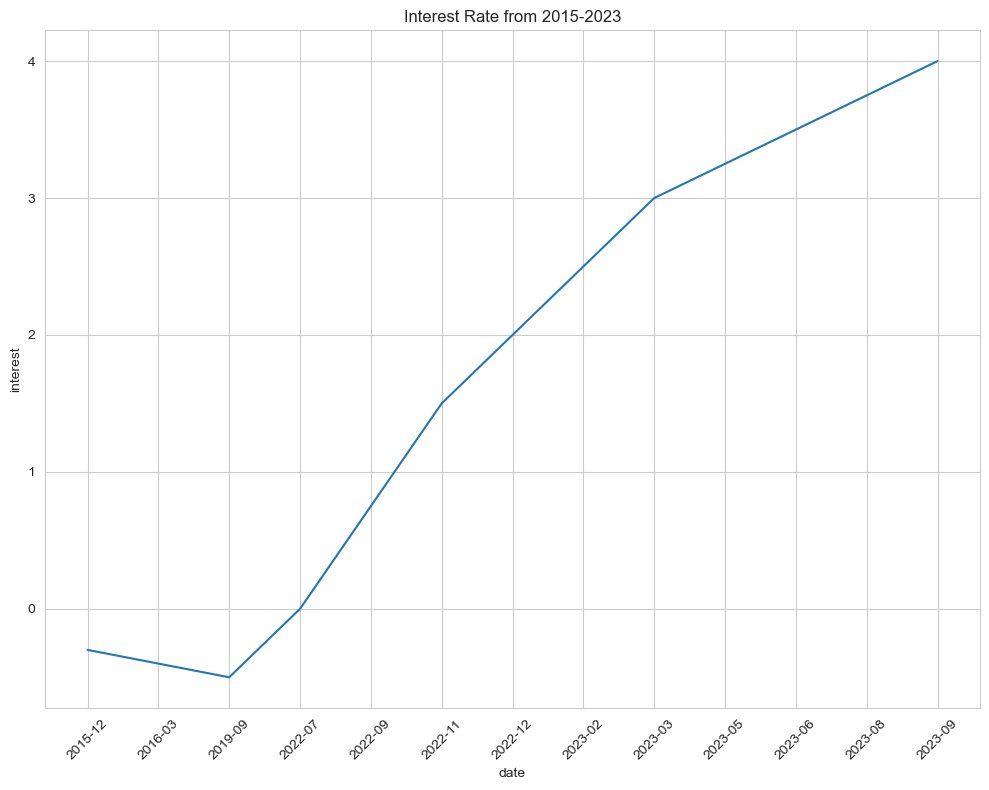

In [228]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,8))
sns.lineplot(data=df_ecb, x='date', y='interest')

plt.xticks(rotation=45)
plt.title('Interest Rate from 2015-2023')
plt.tight_layout()
plt.show()

##### What this graph shows - 
#### Interest rates rise sharply (2022–2023) -- this is a reaction to inflation


----


## Energy rates data

#### Viewing the data

In [229]:
energy_url = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/3.0/data/dataflow/ESTAT/prc_hicp_minr/1.0/*.*.*.*?c[freq]=M&c[unit]=I25,I15,RCH_M,RCH_A,RCH_MV12MAVR&c[coicop18]=TOTAL,CP01,CP011,CP0111,CP01111&c[geo]=EU,EU27_2020,EA,EA21,EA20,EA19,BE,BG,CZ,DK,DE,EE,IE,EL,ES,FR,HR,IT,CY,LV,LT,LU,HU,MT,NL,AT,PL,PT,RO,SI,SK,FI,SE,EEA,IS,NO,CH,UK,ME,MK,GE,AL,RS,TR,XK,US&c[TIME_PERIOD]=ge:2014-02+le:2026-03&compress=false&format=csvdata&formatVersion=1.0&lang=en&labels=label_only"
response = requests.get(energy_url)
response.raise_for_status()

df_energy = pd.read_csv(energy_url)

df_energy.head(5)

C:\Users\meisn\AppData\Local\Temp\ipykernel_18136\4036429009.py:5: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_energy = pd.read_csv(energy_url)


,DATAFLOW,LAST UPDATE,freq,unit,coicop18,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2015-12,100.00,NaN,NaN
1,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2016-01,102.52,NaN,NaN
2,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2016-02,105.91,NaN,NaN
3,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2016-03,107.05,NaN,NaN
4,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2016-04,105.92,NaN,NaN


In [230]:
df_energy.tail()

,DATAFLOW,LAST UPDATE,freq,unit,coicop18,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
144737,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,Moving 12 months average rate of change,Total,Kosovo*,2025-10,3.1,NaN,NaN
144738,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,Moving 12 months average rate of change,Total,Kosovo*,2025-11,3.5,NaN,NaN
144739,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,Moving 12 months average rate of change,Total,Kosovo*,2025-12,3.9,NaN,NaN
144740,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,Moving 12 months average rate of change,Total,Kosovo*,2026-01,4.2,NaN,NaN
144741,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,Moving 12 months average rate of change,Total,Kosovo*,2026-02,4.6,NaN,NaN


In [231]:
df_energy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144742 entries, 0 to 144741
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATAFLOW     144742 non-null  object 
 1   LAST UPDATE  144742 non-null  object 
 2   freq         144742 non-null  object 
 3   unit         144742 non-null  object 
 4   coicop18     144742 non-null  object 
 5   geo          144742 non-null  object 
 6   TIME_PERIOD  144742 non-null  object 
 7   OBS_VALUE    144742 non-null  float64
 8   OBS_FLAG     1474 non-null    object 
 9   CONF_STATUS  0 non-null       float64
dtypes: float64(2), object(8)
memory usage: 11.0+ MB


In [232]:
df_energy.describe()

,OBS_VALUE,CONF_STATUS
count,144742.000000,0.0
mean,40.907355,NaN
std,49.519905,NaN
min,-17.200000,NaN
25%,0.600000,NaN
50%,4.400000,NaN
75%,93.737500,NaN
max,235.610000,NaN


In [233]:
df_energy.isnull().sum()

DATAFLOW            0
LAST UPDATE         0
freq                0
unit                0
coicop18            0
geo                 0
TIME_PERIOD         0
OBS_VALUE           0
OBS_FLAG       143268
CONF_STATUS    144742
dtype: int64

In [234]:
df_energy['geo'].unique()

array(['Albania', 'Austria', 'Belgium', 'Bulgaria', 'Switzerland',
       'Cyprus', 'Czechia', 'Germany', 'Denmark',
       'Euro area (EA11-1999, EA12-2001, EA13-2007, EA15-2008, EA16-2009, EA17-2011, EA18-2014, EA19-2015, EA20-2023, EA21-2026)',
       'Euro area - 19 countries  (2015-2022)',
       'Euro area – 20 countries (2023-2025)',
       'Euro area – 21 countries (from 2026)', 'Estonia',
       'European Economic Area (EEA18-1995, EEA28-2004, EEA30-2007, EEA31-2013, EEA30-2020)',
       'Greece', 'Spain',
       'European Union (EU6-1958, EU9-1973, EU10-1981, EU12-1986, EU15-1995, EU25-2004, EU27-2007, EU28-2013, EU27-2020)',
       'European Union - 27 countries (from 2020)', 'Finland', 'France',
       'Georgia', 'Croatia', 'Hungary', 'Ireland', 'Iceland', 'Italy',
       'Lithuania', 'Luxembourg', 'Latvia', 'Montenegro',
       'North Macedonia', 'Malta', 'Netherlands', 'Norway', 'Poland',
       'Portugal', 'Romania', 'Serbia', 'Sweden', 'Slovenia', 'Slovakia',
       'Ko

In [235]:
df_energy['LAST UPDATE'].unique()

array(['31/03/26 11:00:00'], dtype=object)

In [236]:
df_energy['TIME_PERIOD'].unique()

array(['2015-12', '2016-01', '2016-02', '2016-03', '2016-04', '2016-05',
       '2016-06', '2016-07', '2016-08', '2016-09', '2016-10', '2016-11',
       '2016-12', '2017-01', '2017-02', '2017-03', '2017-04', '2017-05',
       '2017-06', '2017-07', '2017-08', '2017-09', '2017-10', '2017-11',
       '2017-12', '2018-01', '2018-02', '2018-03', '2018-04', '2018-05',
       '2018-06', '2018-07', '2018-08', '2018-09', '2018-10', '2018-11',
       '2018-12', '2019-01', '2019-02', '2019-03', '2019-04', '2019-05',
       '2019-06', '2019-07', '2019-08', '2019-09', '2019-10', '2019-11',
       '2019-12', '2020-01', '2020-02', '2020-03', '2020-04', '2020-05',
       '2020-06', '2020-07', '2020-08', '2020-09', '2020-10', '2020-11',
       '2020-12', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05',
       '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11',
       '2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05',
       '2022-06', '2022-07', '2022-08', '2022-09', 

-----


In [237]:
# Changing columns
df_energy.columns = df_energy.columns.str.replace(' ', '_')
df_energy.columns = map(str.lower, df_energy.columns)
df_energy.head()


,dataflow,last_update,freq,unit,coicop18,geo,time_period,obs_value,obs_flag,conf_status
0,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2015-12,100.00,NaN,NaN
1,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2016-01,102.52,NaN,NaN
2,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2016-02,105.91,NaN,NaN
3,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2016-03,107.05,NaN,NaN
4,ESTAT:PRC_HICP_MINR(1.0),31/03/26 11:00:00,Monthly,"Index, 2015=100",Food and non-alcoholic beverages,Albania,2016-04,105.92,NaN,NaN


In [238]:
# Rename
df_energy = df_energy.rename(columns={"geo": "country", "time_period": "date", "obs_value": "energy"})

# Keep only needed columns
df_energy = df_energy[[ "date", "country", 'energy']]


df_energy.head()

,date,country,energy
0,2015-12,Albania,100.00
1,2016-01,Albania,102.52
2,2016-02,Albania,105.91
3,2016-03,Albania,107.05
4,2016-04,Albania,105.92


In [239]:
for i in df_energy:
  print(df_energy['country'].unique())

['Albania' 'Austria' 'Belgium' 'Bulgaria' 'Switzerland' 'Cyprus' 'Czechia'
 'Germany' 'Denmark'
 'Euro area (EA11-1999, EA12-2001, EA13-2007, EA15-2008, EA16-2009, EA17-2011, EA18-2014, EA19-2015, EA20-2023, EA21-2026)'
 'Euro area - 19 countries  (2015-2022)'
 'Euro area – 20 countries (2023-2025)'
 'Euro area – 21 countries (from 2026)' 'Estonia'
 'European Economic Area (EEA18-1995, EEA28-2004, EEA30-2007, EEA31-2013, EEA30-2020)'
 'Greece' 'Spain'
 'European Union (EU6-1958, EU9-1973, EU10-1981, EU12-1986, EU15-1995, EU25-2004, EU27-2007, EU28-2013, EU27-2020)'
 'European Union - 27 countries (from 2020)' 'Finland' 'France' 'Georgia'
 'Croatia' 'Hungary' 'Ireland' 'Iceland' 'Italy' 'Lithuania' 'Luxembourg'
 'Latvia' 'Montenegro' 'North Macedonia' 'Malta' 'Netherlands' 'Norway'
 'Poland' 'Portugal' 'Romania' 'Serbia' 'Sweden' 'Slovenia' 'Slovakia'
 'Kosovo*' 'United Kingdom' 'United States']
['Albania' 'Austria' 'Belgium' 'Bulgaria' 'Switzerland' 'Cyprus' 'Czechia'
 'Germany' 'Denma

In [240]:
# Filter countries
df_energy = df_energy[df_energy["country"].isin(["Germany","Spain","France","Italy"])]

for i in df_energy:
  print(df_energy['country'].unique())

['Germany' 'Spain' 'France' 'Italy']
['Germany' 'Spain' 'France' 'Italy']
['Germany' 'Spain' 'France' 'Italy']


In [241]:
# Changing country names

country_names = {"Germany": "DE","Spain": "ES", "France": "FR","Italy": "IT"}

df_energy["country"] = df_energy["country"].replace(country_names)

In [242]:
# Fix types
df_energy["date"] = pd.to_datetime(df_energy["date"], errors="coerce")
df_energy.head()

,date,country,energy
991,2014-02-01,DE,100.34
992,2014-03-01,DE,99.91
993,2014-04-01,DE,99.58
994,2014-05-01,DE,99.30
995,2014-06-01,DE,99.21


In [243]:
df_energy["energy"] = pd.to_numeric(df_energy["energy"], errors="coerce")

df_energy.head

<bound method NDFrame.head of              date country  energy
991    2014-02-01      DE  100.34
992    2014-03-01      DE   99.91
993    2014-04-01      DE   99.58
994    2014-05-01      DE   99.30
995    2014-06-01      DE   99.21
...           ...     ...     ...
142271 2025-10-01      IT    1.70
142272 2025-11-01      IT    1.60
142273 2025-12-01      IT    1.60
142274 2026-01-01      IT    1.60
142275 2026-02-01      IT    1.60

[14340 rows x 3 columns]>

In [244]:
# Filter time
df_energy = df_energy[(df_energy["date"] >= "2018-01-01") & (df_energy["date"] <= "2023-12-31")]
df_energy.head(3)

,date,country,energy
1038,2018-01-01,DE,106.35
1039,2018-02-01,DE,106.22
1040,2018-03-01,DE,106.49


In [245]:
# Format
df_energy["date"] = df_energy["date"].dt.to_period("M").astype(str)

C:\Users\meisn\AppData\Local\Temp\ipykernel_18136\1220395722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_energy["date"] = df_energy["date"].dt.to_period("M").astype(str)


In [246]:
df_energy

,date,country,energy
1038,2018-01,DE,106.35
1039,2018-02,DE,106.22
1040,2018-03,DE,106.49
1041,2018-04,DE,106.51
1042,2018-05,DE,106.65
...,...,...,...
142245,2023-08,IT,9.20
142246,2023-09,IT,8.80
142247,2023-10,IT,7.90
142248,2023-11,IT,6.90


In [247]:
df_energy.to_csv("energy_clean.csv", index=False)

----

#### Visuals for dataset

<Axes: xlabel='date', ylabel='country'>

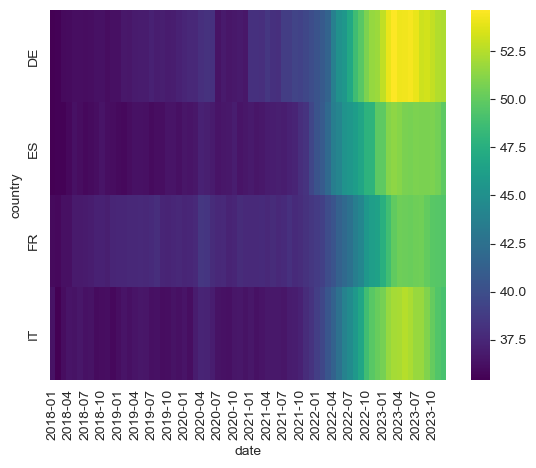

In [248]:
pivot = df_energy.pivot_table(index="country", columns="date", values="energy")
sns.heatmap(pivot, cmap="viridis")

<Axes: xlabel='country', ylabel='energy'>

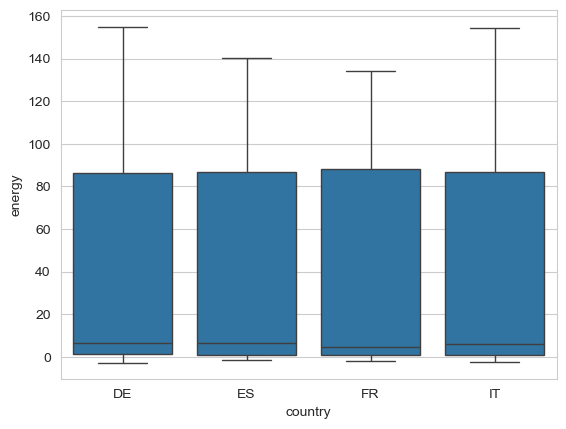

In [249]:
sns.boxplot(data=df_energy, x="country", y="energy")

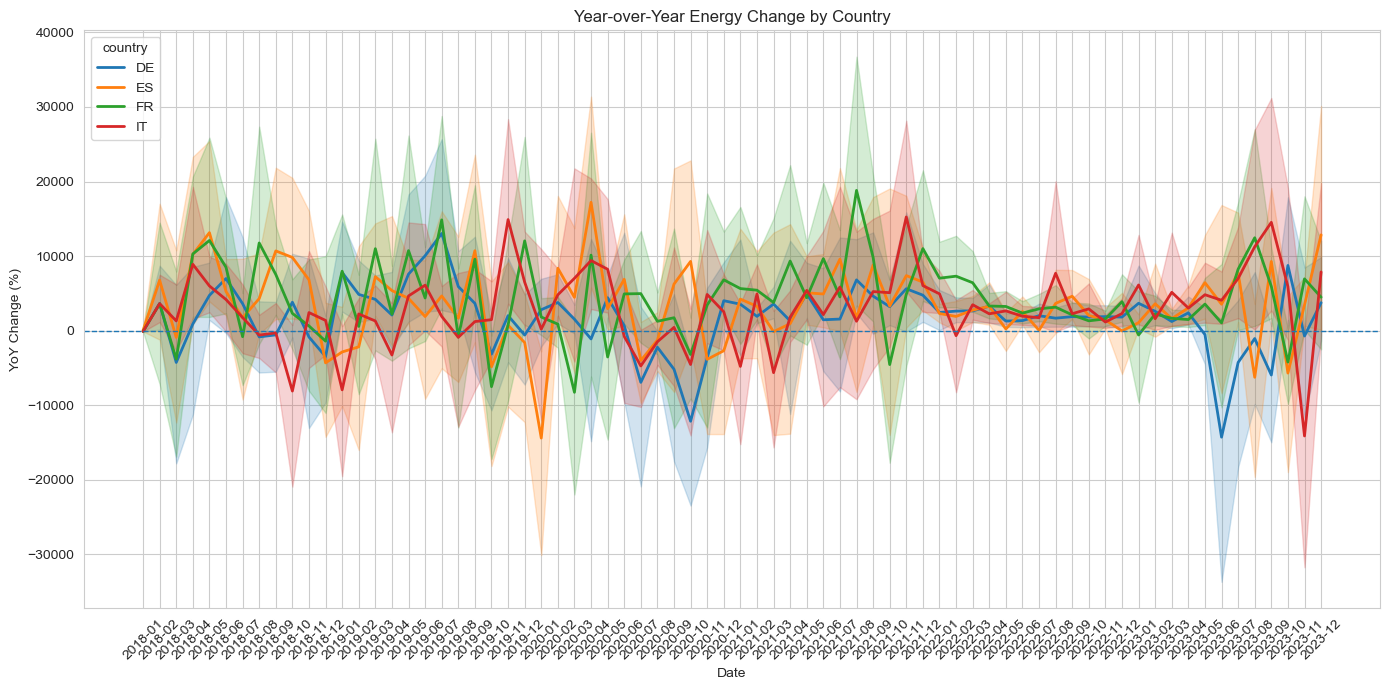

In [ ]:
df_growth = df_energy
df_growth = df_growth.sort_values(["country", "date"])

df_growth["energy_yoy_pct"] = (
    df_growth.groupby("country")["energy"].pct_change(periods=12) * 100
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=df_growth,
    x="date",
    y="energy_yoy_pct",
    hue="country",
    linewidth=2
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Year over Year Energy Change by Country")
plt.xlabel("Date")
plt.ylabel("YoY Change (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()